In [1]:
list_of_packages <- c(
       "ggplot2",
       "dplyr",
       "tidyr",
       "ComplexHeatmap",
       "tibble",
       "RColorBrewer",
       "scales",
       "circlize",
       "argparse"
)
if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager")

if (!requireNamespace("ComplexHeatmap", quietly = TRUE)) {
    BiocManager::install("ComplexHeatmap")
}
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [ ]:
parser <- ArgumentParser(description = "Consensus Profiles Analysis")
parser$add_argument("--patient", type = "character", required = TRUE, help = "Input file path")
args <- parser$parse_args()
patient_id <- args$patient

In [3]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))

In [4]:
sc_consensus_df <- arrow::read_parquet(file.path(root_dir,"data/profiles_3D/", patient_id,"/8.consensus_profiles/sc_consensus.parquet"))

organoid_consensus_df <- arrow::read_parquet(file.path(root_dir,"data/profiles_3D/", patient_id,"/8.consensus_profiles/organoid_consensus.parquet"))

viability_scores_df <- arrow::read_parquet(file.path(root_dir,"data/viabilities/combined_platemaps.parquet"))
sc_consensus_heatmap_file_path <- file.path(
    root_dir,
    paste0("1.EDA/figures/consensus_heatmaps/",patient_id, "_sc_consensus_heatmap.png")
)
organoid_consensus_heatmap_file_path <- file.path(
    root_dir,
    paste0("1.EDA/figures/consensus_heatmaps/", patient_id, "_organoid_consensus_heatmap.png")
)

if (!dir.exists(file.path(root_dir,paste0("1.EDA/figures/consensus_heatmaps/")))) {
    dir.create(file.path(root_dir,paste0("1.EDA/figures/consensus_heatmaps/")), recursive = TRUE)
}

## Single-cell heatmap of consensus profiles

In [5]:
# drop columns that contain neighbors
sc_consensus_df <- sc_consensus_df %>%
  select(-contains("Neighbors"))

# merge the viability scores with the consensus profiles
sc_consensus_df <- merge(
    x = sc_consensus_df,
    y = viability_scores_df %>% filter(patient_id == patient_id),
    by.x = c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose"),
    by.y = c("patient_id", "Treatment", "Dose"),
    all.x = TRUE
)
# drop duplicate rows after the merge
sc_consensus_df <- sc_consensus_df %>%
  distinct()
sc_consensus_df$Metadata_Experiment_Treatment_Full <- paste(sc_consensus_df$Metadata_Experiment_Treatment, sc_consensus_df$Metadata_Experiment_Dose, sep = "_")

sc_consensus_df$Metadata_Experiment_Treatment <- factor(sc_consensus_df$Metadata_Experiment_Treatment, levels = custom_treatment_order)
sc_consensus_df$Metadata_Experiment_MOA <- treatment_moa_map[sc_consensus_df$Metadata_Experiment_Treatment]


In [6]:
if (all(is.na(sc_consensus_df$Metadata_Viability_percentage))) {
    # this patient has no viability data - show a flat grey "None" bar instead of a continuous scale
    viability_values <- rep("None", nrow(sc_consensus_df))
    viability_col <- c("None" = "grey")
} else {
    viability_col_fun <- colorRamp2(
        c(min(sc_consensus_df$Metadata_Viability_percentage, na.rm = TRUE),
          max(sc_consensus_df$Metadata_Viability_percentage, na.rm = TRUE)),
        c("white", "darkgreen")
    )
    viability_values <- sc_consensus_df$Metadata_Viability_percentage
    viability_col <- viability_col_fun
}


column_anno <- HeatmapAnnotation(
    Treatment = sc_consensus_df$Metadata_Experiment_Treatment,
    Target = sc_consensus_df$Metadata_Experiment_MOA,
    Dose = as.character(sc_consensus_df$Metadata_Experiment_Dose),
    Viability = viability_values,
    show_legend = TRUE,
    annotation_name_gp = gpar(fontsize = 16),
    annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    col = list(
        Viability = viability_col,
        Treatment = custom_treatment_palette,
        Target = custom_MOA_palette,
        Dose = dose_palette
    )
)

In [7]:
# get the list of features
features <- colnames(sc_consensus_df)
features <- features[!features %in% c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose", "Metadata_Experiment_Treatment_Full", "Unit", "Drug", "Concentration_uM", "Metadata_Viability_percentage", "min_max_viability", "Metadata_Experiment_MOA")]
features <- as.data.frame(features)
rownames(features) <- features$features
# split the features by _ into multiple columns
features <- features %>% 
    separate(features, into = c("Compartment", "Channel", "Feature Type", "Measurement"), sep = "_", extra = "merge", fill = "right")
# select the first channel for colocalization features channels are split by .
features <- features %>%
    mutate(
        Channel = ifelse(`Feature Type` == "Colocalization", 
                         sub("-.*", "", Channel), 
                         Channel)
    )


# sort by feature type
features <- features %>%
    arrange(`Feature Type`, Compartment, Channel, Measurement)

In [8]:
# compartment row annotation
row_compartment = rowAnnotation(
    Object = features$Compartment,
        show_legend = TRUE,
    # change the legend titles
    annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    annotation_name_side = "bottom",
    annotation_name_gp = gpar(fontsize = 16),
    # color
    col = list(
        Object = sc_compartment_palette
    )
)
row_measurement = rowAnnotation(
    FeatureType = features$`Feature Type`,
           annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 0.5),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    annotation_name_side = "bottom",
    annotation_name_gp = gpar(fontsize = 16),
    col = list(
            FeatureType = feature_type_palette
    ),
    show_legend = TRUE
)
row_channel = rowAnnotation(
    Channel = features$Channel,
        annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 0.5),
        labels_gp = gpar(fontsize = 16, 
        # make annotation bar text bigger
        legend = gpar(fontsize = 16),
        annotation_name = gpar(fontsize = 16),
        # legend_height = unit(20, "cm"),
        legend_width = unit(1, "cm"),
        # make legend taller
        # legend_height = unit(10, "cm"),
        legend_width = unit(1, "cm"),
        legend_key = gpar(fontsize = 16)
        )
    ),


        
    annotation_name_side = "bottom",
    # make font size bigger
    annotation_name_gp = gpar(fontsize = 16),
    col = list(
    Channel = channel_palette
    )
)
row_annotations = c(row_compartment, row_measurement, row_channel)

In [9]:
mat <- sc_consensus_df %>%
  select(-Metadata_Biology_PatientTumor, -Metadata_Experiment_Treatment, -Metadata_Experiment_Dose, -Metadata_Experiment_Treatment_Full, -Unit, -Drug, -Concentration_uM, -Metadata_Viability_percentage, -min_max_viability, -Metadata_Experiment_MOA) %>% 
  as.matrix()
mat <- t(mat)
colnames(mat) <- sc_consensus_df$Metadata_Experiment_Treatment
# clip extreme outlier values so they don't wash out the color scale
mat[mat > 10] <- 10
mat[mat < -10] <- -10

png 
  2

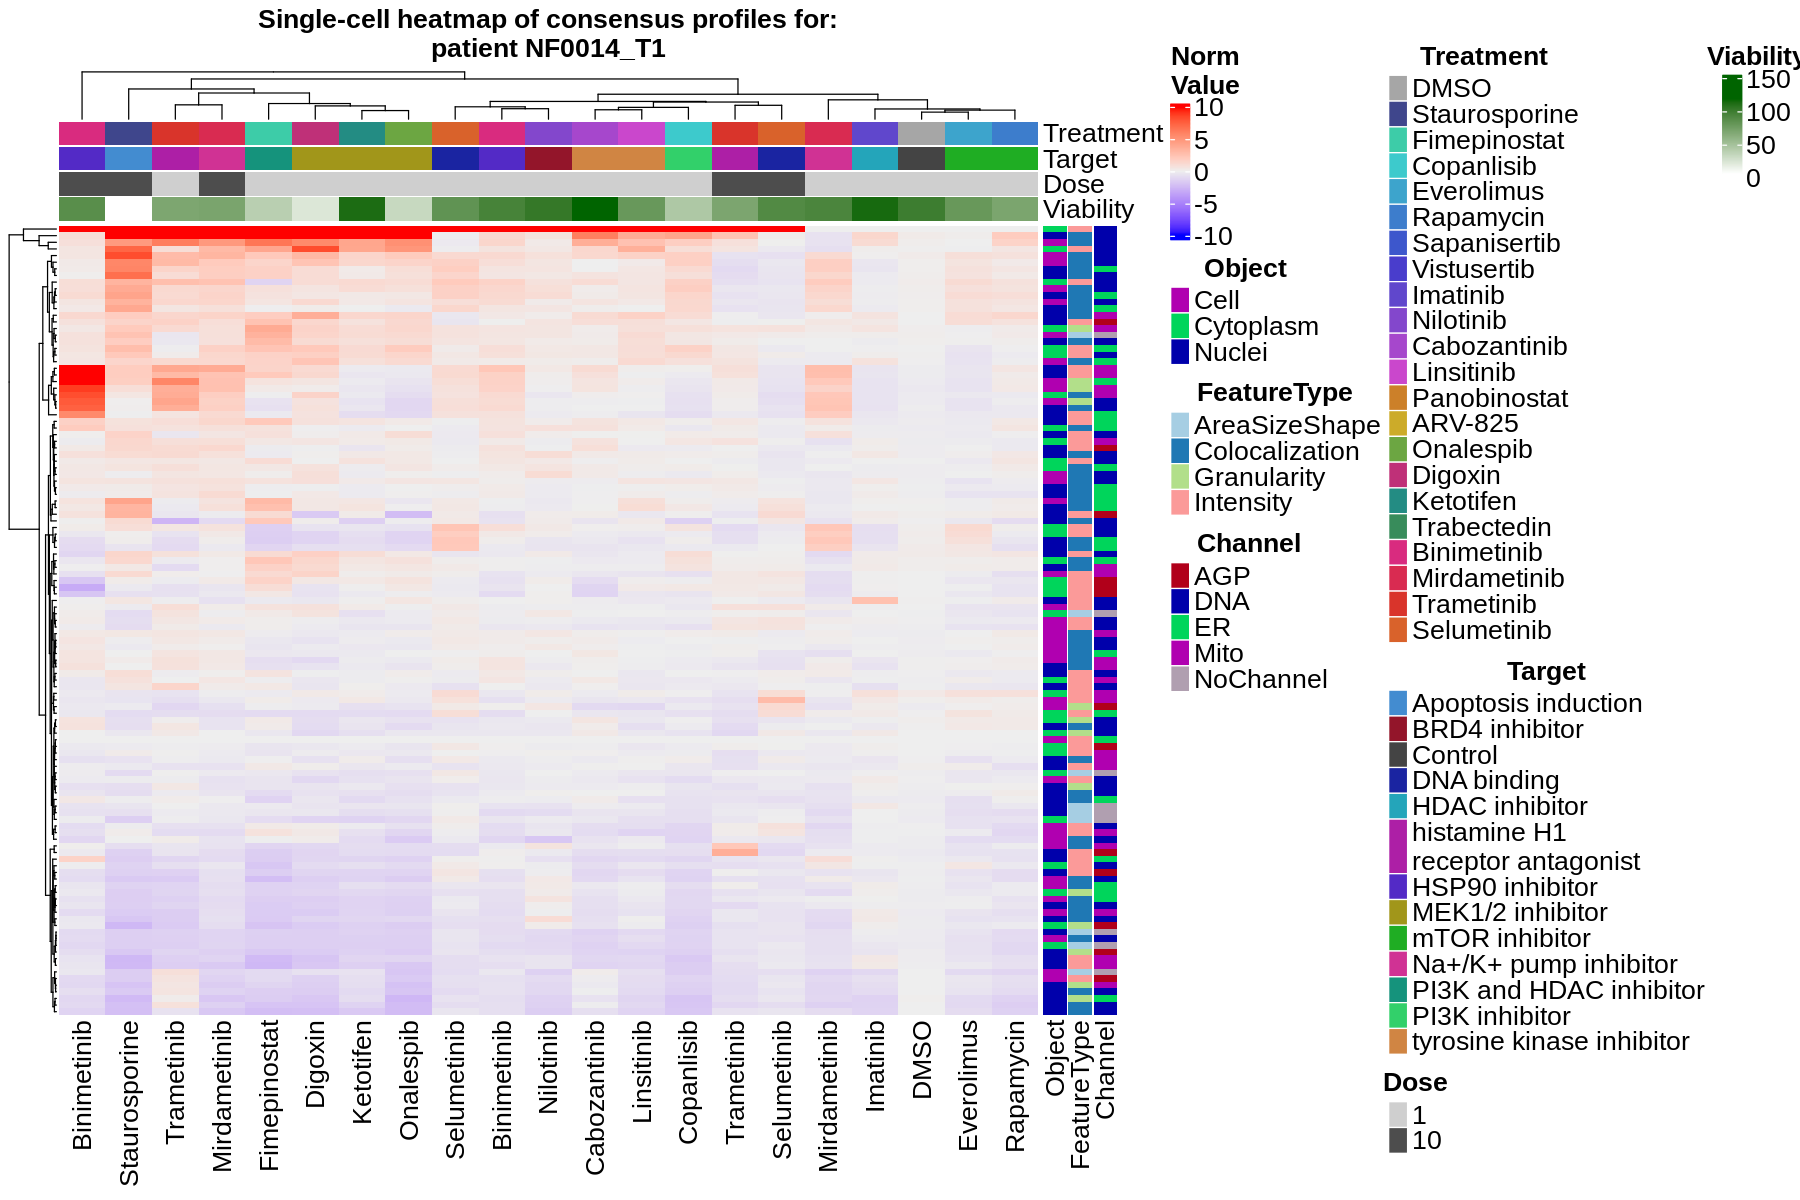

In [10]:
width <- 15
height <- 10
options(repr.plot.width = width, repr.plot.height = height)
heatmap_plot <- Heatmap(
        mat, 
        # col = col_fun,
        show_row_names = FALSE,
        # cluster_columns = FALSE,
        show_column_names = TRUE,

        column_names_gp = gpar(fontsize = 16), # Column name label formatting
        row_names_gp = gpar(fontsize = 14), 

        # show_heatmap_legend = FALSE,
        heatmap_legend_param = list(
                    title = "Norm\nValue",
                    title_position = "topcenter", 
                    title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
                    labels_gp = gpar(fontsize = 16),
                    # legend_height = unit(2, "cm"),
                    legend_width = unit(3, "cm"),
                    annotation_legend_side = "bottom"
                    ), 
        
        right_annotation = row_annotations,
        top_annotation = column_anno,
        column_title = paste0("Single-cell heatmap of consensus profiles for:\npatient ", patient_id),
        # adjust the title position and size
        column_title_gp = gpar(fontsize = 16, fontface = "bold", hjust = 0.5),
    
    )
png(sc_consensus_heatmap_file_path, width = width, height = height, units = "in", res = 300)
# save as a PNG
draw(heatmap_plot, merge_legend = TRUE, heatmap_legend_side = "right")
dev.off()
heatmap_plot

## Organoid heatmap of consensus profiles

In [11]:
# drop columns that contain neighbors
organoid_consensus_df <- organoid_consensus_df %>%
  select(-contains("Neighbors"))

# merge the viability scores with the consensus profiles
organoid_consensus_df <- merge(
    x = organoid_consensus_df,
    y = viability_scores_df %>% filter(patient_id == patient_id),
    by.x = c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose"),
    by.y = c("patient_id", "Treatment", "Dose"),
    all.x = TRUE
)
# drop duplicate rows after the merge
organoid_consensus_df <- organoid_consensus_df %>%
  distinct()
organoid_consensus_df$Metadata_Experiment_Treatment_Full <- paste(organoid_consensus_df$Metadata_Experiment_Treatment, organoid_consensus_df$Metadata_Experiment_Dose, sep = "_")

organoid_consensus_df$Metadata_Experiment_Treatment <- factor(organoid_consensus_df$Metadata_Experiment_Treatment, levels = custom_treatment_order)
organoid_consensus_df$Metadata_Experiment_MOA <- treatment_moa_map[organoid_consensus_df$Metadata_Experiment_Treatment]

In [12]:
if (all(is.na(organoid_consensus_df$Metadata_Viability_percentage))) {
    # this patient has no viability data - show a flat grey "None" bar instead of a continuous scale
    viability_values <- rep("None", nrow(organoid_consensus_df))
    viability_col <- c("None" = "grey")
} else {
    viability_col_fun <- colorRamp2(
        c(min(organoid_consensus_df$Metadata_Viability_percentage, na.rm = TRUE),
          max(organoid_consensus_df$Metadata_Viability_percentage, na.rm = TRUE)),
        c("white", "darkgreen")
    )
    viability_values <- organoid_consensus_df$Metadata_Viability_percentage
    viability_col <- viability_col_fun
}

dose_palette <- c(
    "1" = "#CFCFCF",
    "10" = "#4D4D4D"
)

column_anno <- HeatmapAnnotation(
    Treatment = organoid_consensus_df$Metadata_Experiment_Treatment,
    Target = organoid_consensus_df$Metadata_Experiment_MOA,
    Dose = as.character(organoid_consensus_df$Metadata_Experiment_Dose),
    Viability = viability_values,
    show_legend = TRUE,
    annotation_name_gp = gpar(fontsize = 16),
    annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    col = list(
        Viability = viability_col,
        Treatment = custom_treatment_palette,
        Target = custom_MOA_palette,
        Dose = dose_palette
    )
)

In [13]:
# get the list of features
features <- colnames(organoid_consensus_df)
features <- features[!features %in% c("Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment", "Metadata_Experiment_Dose", "Metadata_Experiment_Treatment_Full", "Unit", "Drug", "Concentration_uM", "Metadata_Viability_percentage", "min_max_viability","Metadata_Experiment_MOA")]
features <- as.data.frame(features)
rownames(features) <- features$features
# split the features by _ into multiple columns
features <- features %>% 
    separate(features, into = c("Compartment", "Channel", "Feature Type", "Measurement"), sep = "_", extra = "merge", fill = "right")
# select the first channel for colocalization features channels are split by .
features <- features %>%
    mutate(
        Channel = ifelse(`Feature Type` == "Colocalization", 
                         sub("-.*", "", Channel), 
                         Channel)
    )
# sort by feature type
features <- features %>%
    arrange(`Feature Type`, Compartment, Channel, Measurement)

In [14]:
# compartment row annotation
row_compartment = rowAnnotation(
    Object = features$Compartment,
        show_legend = TRUE,
    # change the legend titles
    annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    annotation_name_side = "bottom",
    annotation_name_gp = gpar(fontsize = 16),
    # color
    col = list(
        Object = organoid_compartment_palette
    )
)
row_measurement = rowAnnotation(
    FeatureType = features$`Feature Type`,
           annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 0.5),
        labels_gp = gpar(fontsize = 16, 
        title = gpar(fontsize = 16))),
    annotation_name_side = "bottom",
    annotation_name_gp = gpar(fontsize = 16),
    col = list(
            FeatureType = feature_type_palette
    ),
    show_legend = TRUE
)
row_channel = rowAnnotation(
    Channel = features$Channel,
        annotation_legend_param = list(
        title_position = "topcenter", 
        title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 0.5),
        labels_gp = gpar(fontsize = 16, 
        # make annotation bar text bigger
        legend = gpar(fontsize = 16),
        annotation_name = gpar(fontsize = 16),
        # legend_height = unit(20, "cm"),
        legend_width = unit(1, "cm"),
        # make legend taller
        # legend_height = unit(10, "cm"),
        legend_width = unit(1, "cm"),
        legend_key = gpar(fontsize = 16)
        )
    ),


        
    annotation_name_side = "bottom",
    # make font size bigger
    annotation_name_gp = gpar(fontsize = 16),
    col = list(
    Channel = channel_palette
    )
)
row_annotations = c(row_compartment, row_measurement, row_channel)

In [15]:
mat <- organoid_consensus_df %>%
  select(-Metadata_Biology_PatientTumor, -Metadata_Experiment_Treatment, -Metadata_Experiment_Dose, -Metadata_Experiment_Treatment_Full, -Unit, -Drug, -Concentration_uM, -Metadata_Viability_percentage, -min_max_viability, -Metadata_Experiment_MOA) %>% 
  as.matrix()
mat <- t(mat)
colnames(mat) <- organoid_consensus_df$Metadata_Experiment_Treatment_Full
# clip extreme outlier values so they don't wash out the color scale
mat[mat > 10] <- 10
mat[mat < -10] <- -10

png 
  2

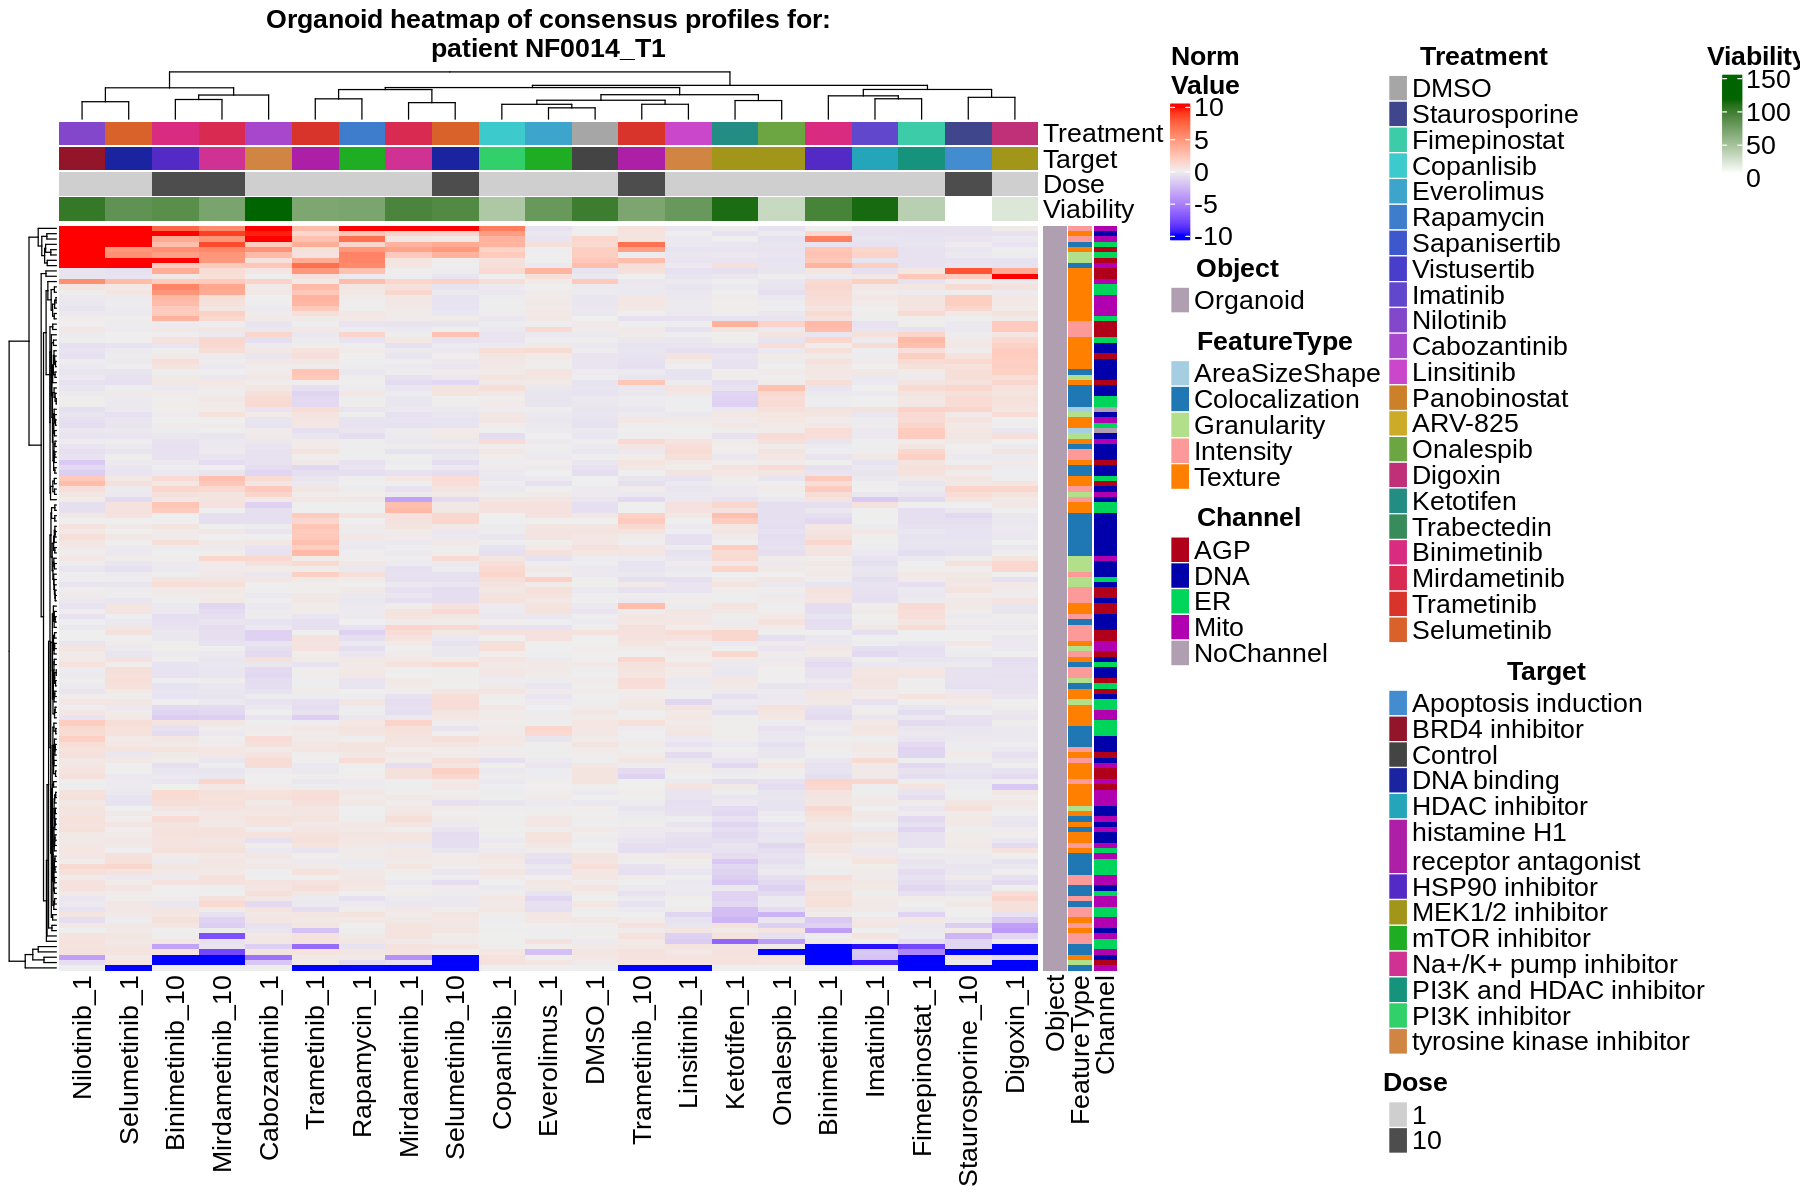

In [16]:
width <- 15
height <- 10
options(repr.plot.width = width, repr.plot.height = height)
heatmap_plot <- Heatmap(
        mat, 
        # col = col_fun,
        show_row_names = FALSE,
        # cluster_columns = FALSE,
        show_column_names = TRUE,

        column_names_gp = gpar(fontsize = 16), # Column name label formatting
        row_names_gp = gpar(fontsize = 14), 

        # show_heatmap_legend = FALSE,
        heatmap_legend_param = list(
                    title = "Norm\nValue",
                    title_position = "topcenter", 
                    title_gp = gpar(fontsize = 16, angle = 0, fontface = "bold", hjust = 1.0),
                    labels_gp = gpar(fontsize = 16),
                    # legend_height = unit(2, "cm"),
                    legend_width = unit(3, "cm"),
                    annotation_legend_side = "bottom"
                    ), 
        
        # row_dend_width = unit(2, "cm"),
        # column_title = paste0("Dose: ", dose," uM"),
        right_annotation = row_annotations,
        top_annotation = column_anno,
        column_title = paste0("Organoid heatmap of consensus profiles for:\npatient ", patient_id),
        # adjust the title position and size
        column_title_gp = gpar(fontsize = 16, fontface = "bold", hjust = 0.5),
    
    )

png(organoid_consensus_heatmap_file_path, width = width, height = height, units = "in", res = 300)
draw(heatmap_plot, merge_legend = TRUE, heatmap_legend_side = "right")
dev.off()
heatmap_plot